# PRE-01 · Mathematical Language and Arithmetic

*Your first conversation with the language of machine learning*

Math can look like a wall of symbols when nobody pauses to translate it.
We will translate every symbol, calculate with tiny numbers, and check the
same idea in Python. No speed contest. No hidden steps.

| Lesson information | Value |
|---|---|
| Prerequisites | None |
| First-pass time | About 3–4 hours with practice |
| You are finished when | You can explain and calculate without copying |

> **Keep this nearby:** when a formula looks dense, read one symbol at a time.
> A formula is an instruction, not a test of whether you are “a math person.”


> **Canonical learner route · module PRE-01 of 67**
>
> Required prerequisites: **none** · Previous: **entry diagnostic** ·
> Next after mastery: **PRE-02** · Expected first-pass workload:
> **2–4 hours**
>
> **Core path:** intuition, objectives, foundations, runnable implementation,
> failure modes, and assessed exercises. **Extension path:** history, production,
> tradeoffs, and interview material may be revisited after the core pass.
> Do not continue merely because every cell ran. Continue when you can complete
> the independent exercise and teach-back without notes. The canonical route in
> `docs/CURRICULUM_PATH.json` is authoritative when section-local file order and
> prerequisite order differ.


## 1 · What you will be able to do

By the end of this lesson, you will be able to:

- move confidently between positive and negative numbers;
- choose the correct arithmetic operation for a practical question;
- use parentheses and the order of operations without guessing;
- move between fractions, decimals, ratios, and percentages;
- read powers, roots, inequalities, variables, subscripts, and summations;
- keep units attached to a calculation;
- translate a short formula into ordinary language;
- reproduce a manual calculation in Python and verify the result.

Here is the path we will follow:

```text
practical question
    → numbers and operations
    → fractions and percentages
    → variables and compact formulas
    → manual calculation
    → Python verification
    → decision
```


## 2 · Why these symbols exist

A small data pipeline processed **2,000 records**. **30 records failed**.

Is that alarming?

“Thirty failures” sounds bad, but it leaves out the size of the job. Thirty
failures out of forty records would be a crisis. Thirty out of two thousand
is a different situation. To compare them fairly, we need division, a fraction,
and a percentage.

Now imagine we repeat that calculation every day. A sentence such as “divide
the number of failed records by the number processed, then multiply by one
hundred” works, but it is long. A formula stores the same instruction compactly.

Math notation is compression. The benefit is speed and precision. The cost is
that compressed instructions feel mysterious until we unpack them.

That is our job in this lesson: **unpack first, calculate second, compress last.**


## 3 · Build a picture before calculating

Think of a number line as a road:

- zero is the reference point;
- positive numbers are to the right;
- negative numbers are to the left;
- adding a positive number moves right;
- subtracting a positive number moves left;
- distance from zero is never negative.

Start at $-1$ and add $4$. Before looking at the plot, where should you land?
Count four moves to the right: $0$, $1$, $2$, $3$.

The road analogy helps with direction and distance. It stops being useful when
we work with quantities that are not positions, such as categories or matrices.


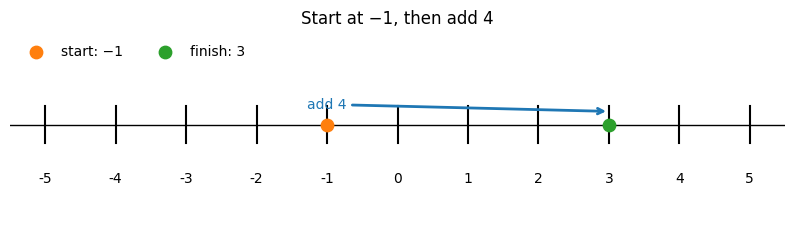

calculation: -1 + 4 = 3


In [1]:
import numpy as np
import matplotlib.pyplot as plt

start = -1
amount_added = 4
destination = start + amount_added

fig, ax = plt.subplots(figsize=(10, 2.4))
ax.axhline(0, color="black", linewidth=1)

for value in range(-5, 6):
    ax.plot([value, value], [-0.07, 0.07], color="black")
    ax.text(value, -0.22, str(value), ha="center")

ax.scatter([start], [0], s=80, color="tab:orange", zorder=3, label="start: −1")
ax.scatter([destination], [0], s=80, color="tab:green", zorder=3, label="finish: 3")
ax.annotate(
    "add 4",
    xy=(destination, 0.05),
    xytext=(start, 0.05),
    arrowprops={"arrowstyle": "->", "color": "tab:blue", "linewidth": 2},
    color="tab:blue",
    ha="center",
    va="bottom",
)
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-0.35, 0.35)
ax.axis("off")
ax.set_title("Start at −1, then add 4")
ax.legend(loc="upper left", ncol=2, frameon=False)
plt.show()

print("calculation:", start, "+", amount_added, "=", destination)
assert destination == 3


**What the picture says:** addition changed the position from $-1$ to $3$.
The arrow shows direction; the tick marks make the four-unit change countable.

**Quick prediction:** where would $3-5$ land? Keep your answer—we will use
subtraction next.


## 4 · The mathematical toolkit

### 4.1 Four operations, four kinds of question

Arithmetic is easier when you start from the question instead of the symbol.

| Question | Operation | Example |
|---|---|---|
| How much altogether? | Addition | $8+3=11$ |
| How much remains, or what is the difference? | Subtraction | $8-3=5$ |
| How many equal groups altogether? | Multiplication | $8\times3=24$ |
| How much in each equal group? | Division | $8\div2=4$ |

Read $8-3=5$ aloud as “eight minus three equals five.” The equals sign means
the expression on the left and the value on the right are the same amount.

Division by zero is undefined. If $8\div0$ had an answer $q$, then
$0\times q$ would need to equal $8$. But zero times every ordinary number is
zero, never eight.

Your earlier prediction was:

$$
3-5=-2
$$

**Symbols:** $-$ means subtract. The result $-2$ is two units left of zero.


### 4.2 Parentheses and order of operations

Parentheses are a “finish this first” signal.

Without parentheses:

$$
2+3\times4=2+12=14
$$

With parentheses:

$$
(2+3)\times4=5\times4=20
$$

**Read aloud:** “two plus three times four” versus “the quantity two plus
three, times four.”

**Symbols and rule:** parentheses group an operation. Multiplication and
division happen before addition and subtraction. Operations at the same level
are handled from left to right.

For example:

$$
20\div5\times2=4\times2=8
$$

A common mistake is to multiply $5\times2$ first. Division and multiplication
have equal priority, so we move from left to right.


### 4.3 Fractions, ratios, decimals, and percentages

These are different views of the same comparison.

Suppose three of four checks passed:

$$
\frac{3}{4}=0.75=75\%
$$

**Read aloud:** “three divided by four equals zero point seven five, which is
seventy-five percent.”

**Symbols:** $3$ is the numerator—the part being counted. $4$ is the
denominator—the total used for comparison. The fraction bar means divide.
The percent sign means “out of one hundred.”

<div style="display: flex; align-items: center; justify-content: center; gap: 10px; margin: 24px 0; flex-wrap: wrap;">
  <div style="border: 2px solid #4c78a8; border-radius: 10px; padding: 12px 16px; text-align: center; background: #eef5ff; color: #172b4d;">
    <strong>Counts</strong><br>
    $3$ passed out of $4$
  </div>
  <div style="font-size: 24px; color: #555;" aria-label="becomes">→</div>
  <div style="border: 2px solid #af7aa1; border-radius: 10px; padding: 12px 16px; text-align: center; background: #f8eff7; color: #3f243b;">
    <strong>Fraction</strong><br>
    $\frac{3}{4}$
  </div>
  <div style="font-size: 24px; color: #555;" aria-label="divide">→</div>
  <div style="border: 2px solid #f28e2b; border-radius: 10px; padding: 12px 16px; text-align: center; background: #fff4e8; color: #4a2b0b;">
    <strong>Decimal</strong><br>
    $3\div4=0.75$
  </div>
  <div style="font-size: 24px; color: #555;" aria-label="multiply by one hundred">→</div>
  <div style="border: 2px solid #59a14f; border-radius: 10px; padding: 12px 16px; text-align: center; background: #eef8ec; color: #173d17;">
    <strong>Percentage</strong><br>
    $0.75\times100=75\%$
  </div>
</div>

Follow the arrows in both directions. Moving right performs a calculation.
Moving left changes the representation without changing the underlying share.

The phrase “three to four” is a ratio and is often written $3:4$. Always state
what each side counts. A number without its comparison group can mislead.

To convert a decimal to a percentage, multiply by $100$:

$$
0.75\times100=75\%
$$

To convert a percentage to a decimal, divide by $100$:

$$
75\%\div100=0.75
$$


### 4.4 Powers and roots

A power repeats multiplication:

$$
3^2=3\times3=9
$$

**Read aloud:** “three squared equals nine.”

**Symbols:** $3$ is the base. The superscript $2$ is the exponent and says
how many factors of $3$ to use.

A square root reverses a square:

$$
\sqrt{9}=3
$$

**Read aloud:** “the principal square root of nine is three.” The radical
symbol $\sqrt{\;}$ asks for the non-negative number whose square is the value
inside it.

Watch the parentheses:

$$
-3^2=-(3^2)=-9
$$

but

$$
(-3)^2=9
$$

Squared errors make large mistakes count more. Square roots can return a
squared quantity to its original unit.


### 4.5 Variables and equations

A variable is a name for a value. Sometimes the value is unknown; sometimes
it is allowed to change.

<div style="display: flex; justify-content: center; gap: 18px; margin: 24px 0; flex-wrap: wrap;">
  <div style="border: 2px solid #4c78a8; border-radius: 10px; padding: 16px 22px; min-width: 220px; background: #eef5ff; color: #172b4d;">
    <strong>Expression</strong><br><br>
    $x+3$<br><br>
    A calculation.<br>
    It has no equals sign.
  </div>
  <div style="border: 2px solid #59a14f; border-radius: 10px; padding: 16px 22px; min-width: 220px; background: #eef8ec; color: #173d17;">
    <strong>Equation</strong><br><br>
    $x+3=8$<br><br>
    A claim that two expressions<br>
    have the same value.
  </div>
</div>

The left side of the equation, $x+3$, is an expression. The right side, $8$,
is another expression. The equals sign connects them and makes a statement we
can solve or check.

$$
x+3=8
$$

**Read aloud:** “x plus three equals eight.”

**Symbols:** $x$ is the unknown value. The equals sign states that both sides
must stay balanced.

Think of an equation as a balanced scale. If we subtract $3$ from one side,
we subtract $3$ from the other side too:

$$
x+3-3=8-3
$$

so

$$
x=5
$$

**Self-check:** replace $x$ with $5$. Because $5+3=8$, the solution works.
The scale analogy explains balance, but an equation is a logical relationship,
not a physical object.


### 4.6 Subscripts and summation

A subscript labels a position. It is not multiplication.

$$
(x_1,x_2,x_3)=(4,7,2)
$$

Here, $x_1=4$, $x_2=7$, and $x_3=2$.

The summation symbol is a compact loop for a human reader:

$$
\sum_{i=1}^{3}x_i=x_1+x_2+x_3
$$

Substitute the values:

$$
4+7+2=13
$$

**Read aloud:** “the sum of x sub i, for i from one through three, equals
thirteen.”

**Symbols:** $\sum$ means repeatedly add. The index $i$ names the current
position. The lower bound $i=1$ says where to begin; the upper bound $3$ says
where to stop. We could rename $i$ without changing the result.


### 4.7 Absolute value

Absolute value measures distance from zero:

$$
|-5|=5
$$

and

$$
|3|=3
$$

**Read aloud:** “the absolute value of negative five is five.”

**Symbols:** the vertical bars around one number mean its distance from zero.
Distance is non-negative. Absolute value is useful when the size of an error
matters but its direction does not.

Later, vertical bars may mean “given” in probability or describe set size.
Context determines the meaning, so we will label those uses when they appear.


### 4.8 Comparisons, intervals, and sets

Comparison symbols let us describe allowed values:

| Symbol | Read it as | Example meaning |
|---|---|---|
| $<$ | less than | $x<5$ excludes 5 |
| $>$ | greater than | $x>5$ excludes 5 |
| $\le$ | less than or equal to | $x\le5$ includes 5 |
| $\ge$ | greater than or equal to | $x\ge5$ includes 5 |

Probability $p$ must satisfy:

$$
0\le p\le1
$$

**Read aloud:** “p is between zero and one, including both ends.” The closed
interval $[0,1]$ says the same thing. Square brackets include the endpoints;
parentheses exclude them, as in $(0,1)$.

A set is a collection. If $A=\{2,4,6\}$, then $4\in A$ means “four belongs
to A,” while $5\notin A$ means “five does not belong to A.”


### 4.9 Scientific notation, approximation, and units

Scientific notation keeps very large and very small values readable:

$$
3.2\times10^4=32{,}000
$$

and

$$
4.5\times10^{-3}=0.0045
$$

**Symbols:** the exponent tells how many places the decimal point moves.
Positive powers of ten make the magnitude larger; negative powers make it
smaller.

The symbol $\approx$ means “approximately equal,” not exactly equal:

$$
\frac{1}{3}\approx0.333
$$

Units are part of the meaning. Sixty kilometres over two hours gives:

$$
\frac{60\text{ km}}{2\text{ h}}=30\text{ km/h}
$$

Kilometres cannot be added directly to hours. Keeping units visible is one
of the cheapest ways to catch a bad calculation.


## 5 · Calculate it by hand before asking Python

A service recorded four request latencies:

$$
100,\;120,\;80,\;140\text{ milliseconds}
$$

**Symbols and units:** each number is one observed request latency. Every value
uses milliseconds, so addition, subtraction, and averaging preserve a clear unit.

**Pause and predict:** should the average be below $80$, between $80$ and
$140$, or above $140$? An average of these values must lie between the smallest
and largest value.

Now calculate:

1. Total: $100+120+80+140=440$ milliseconds.
2. Count: there are $4$ measurements.
3. Average: $440\div4=110$ milliseconds.
4. Range: $140-80=60$ milliseconds.

The average describes a center. The range describes the full observed spread.
Neither number alone tells the complete story.

Next, Python will perform the same additions one value at a time. Predict the
final output before running the cell.


In [2]:
latencies_ms = [100, 120, 80, 140]

running_total_ms = 0
for latency_ms in latencies_ms:
    running_total_ms = running_total_ms + latency_ms
    print("added", latency_ms, "ms → running total:", running_total_ms, "ms")

measurement_count = len(latencies_ms)
average_latency_ms = running_total_ms / measurement_count
latency_range_ms = max(latencies_ms) - min(latencies_ms)

print("\nfinal total:", running_total_ms, "ms")
print("count:", measurement_count)
print("average:", average_latency_ms, "ms")
print("range:", latency_range_ms, "ms")

assert running_total_ms == 440
assert average_latency_ms == 110
assert latency_range_ms == 60


added 100 ms → running total: 100 ms
added 120 ms → running total: 220 ms
added 80 ms → running total: 300 ms
added 140 ms → running total: 440 ms

final total: 440 ms
count: 4
average: 110.0 ms
range: 60 ms


**What happened in the loop:** `running_total_ms` began at zero. Each pass
added one latency. This is the code version of a summation.

The suffix `_ms` keeps the unit visible in the variable name. Python does not
know that these values are milliseconds, so the name helps us protect the
meaning ourselves.


## 6 · See the same numbers as a picture

A chart is another representation of the same four values. Before looking,
predict which bar will be tallest and where the average line will appear.


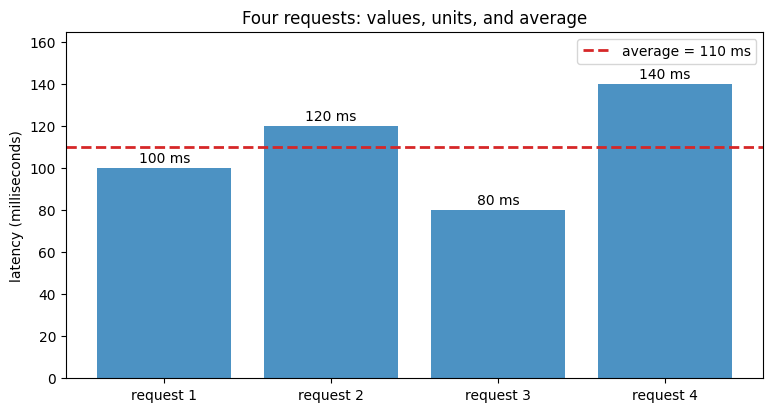

In [3]:
request_labels = ["request 1", "request 2", "request 3", "request 4"]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(request_labels, latencies_ms, color="tab:blue", alpha=0.8)
ax.axhline(
    average_latency_ms,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="average = 110 ms",
)

for bar, latency_ms in zip(bars, latencies_ms):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        latency_ms + 3,
        f"{latency_ms} ms",
        ha="center",
    )

ax.set_ylabel("latency (milliseconds)")
ax.set_title("Four requests: values, units, and average")
ax.set_ylim(0, 165)
ax.legend()
plt.show()


**How to read the chart:** request 4 is tallest at $140$ milliseconds. The
dashed line is the same $110$-millisecond average calculated by hand. A chart
helps us notice patterns quickly, but it does not replace exact values, units,
or a calculation.


## 7 · Mistakes worth making once

These errors are normal. The useful habit is learning how to catch them.

| Common mistake | Why it happens | Quick check |
|---|---|---|
| Reading $x_2$ as $x\times2$ | Subscripts look like small multipliers | Say “x sub two”: it labels position 2 |
| Treating $20\%$ as $20$ | The percent sign is skipped | Convert it to $0.20$ before calculating |
| Ignoring parentheses | The expression is read too quickly | Circle or rewrite the grouped operation |
| Dividing by zero | The denominator was not checked | Ask whether the comparison group can be empty |
| Mixing units | The numbers look compatible | Write the unit beside every intermediate value |
| Trusting an implausible output | Code ran without an exception | Estimate the expected range first |
| Confusing $-3^2$ and $(-3)^2$ | The negative sign may sit outside the power | Rewrite the grouping explicitly |

A calculator and Python can execute a mistaken instruction perfectly. Successful
execution means the instruction was valid code, not that the reasoning was right.


## 8 · Let NumPy do the repeated work

Plain Python exposed every addition. NumPy gives us concise operations for an
entire numerical array. The mathematics stays the same.

Before running the next cell, predict:

- the sum of $(4,7,2)$;
- the shape of the array;
- the two absolute values produced from $(-5,3)$.


In [4]:
values = np.array([4.0, 7.0, 2.0])

total = np.sum(values)
mean = np.mean(values)
squares = values ** 2
square_roots = np.sqrt(values)
absolute_values = np.abs(np.array([-5, 3]))

print("values:", values)
print("shape:", values.shape)
print("sum:", total)
print("mean:", mean)
print("squares:", squares)
print("square roots:", square_roots.round(3))
print("absolute values:", absolute_values)

assert values.shape == (3,)
assert total == 13
assert np.array_equal(absolute_values, np.array([5, 3]))


values: [4. 7. 2.]
shape: (3,)
sum: 13.0
mean: 4.333333333333333
squares: [16. 49.  4.]
square roots: [2.    2.646 1.414]
absolute values: [5 3]


**What the outputs mean:** shape `(3,)` says this is a one-dimensional array
with three positions. `np.sum` performs the same repeated addition as
$\sum_{i=1}^{3}x_i$. `np.abs` calculates distance from zero at each position.

If the shape or total differed from the prediction, inspect the input array
before changing the calculation.


## 9 · Return to the pipeline decision

The pipeline processed $2{,}000$ records and $30$ failed.

Start with the fraction:

$$
\text{failure fraction}=\frac{30}{2000}=0.015
$$

Convert it to a percentage:

$$
\text{failure percentage}=0.015\times100=1.5\%
$$

Successful records:

$$
2000-30=1970
$$

**Symbols and units:** $30$ is the failed-record count, $2{,}000$ is the
processed-record count, and the division produces a unitless fraction.

Is $1.5\%$ acceptable? Arithmetic cannot decide that alone. We need a target,
a previous baseline, and the cost of a failed record. The calculation makes the
decision discussable; it does not make the decision for us.


## 10 · How to study this without memorizing

Use this five-step routine whenever you meet a formula:

1. **Name the question.** What are we trying to find?
2. **Read it aloud.** Turn symbols into an instruction.
3. **Attach meaning.** Label every value and unit.
4. **Use tiny numbers.** Calculate one example by hand.
5. **Verify.** Use Python, an estimate, or an inverse operation.

If paper and Python disagree, do not immediately edit the code until it “looks
right.” Compare one operation at a time. The disagreement is useful evidence.

Fluency means you can explain the steps and notice an implausible result. It does
not mean performing every calculation quickly in your head.


## 11 · Choose the clearest representation

| Representation | Best for | Limitation |
|---|---|---|
| Plain language | Explaining the question and meaning | Can become long or ambiguous |
| Formula | Storing a precise repeated instruction | Feels dense until symbols are translated |
| Code | Repeating and testing a calculation | Can hide incorrect reasoning behind valid syntax |
| Table | Comparing a small set of exact values | Patterns may be slow to notice |
| Chart | Seeing size and pattern quickly | Poor axes can create a misleading impression |

You do not need to choose only one. Strong reasoning moves between language,
formulas, manual numbers, code, and pictures.


### One-page symbol reference

Use this as a quick translation sheet, not a memorization list. When a symbol
appears, say its instruction aloud and attach the real unit or meaning.

| Symbol | Read it as | What it tells you | Tiny example |
| --- | --- | --- | --- |
| $+$ | plus | add quantities | $3+2=5$ |
| $-$ | minus or negative | subtract, or mark a value left of zero | $5-7=-2$ |
| $\times$ | times | multiply | $3\times4=12$ |
| $\div$ or $/$ | divided by | split or compare through division | $8\div2=4$ |
| $=$ | equals | both sides have the same value | $x+1=4$ |
| $\ne$ | is not equal to | the values differ | $3\ne4$ |
| $<$, $>$ | less than, greater than | compare without including the boundary | $2<5$ |
| $\le$, $\ge$ | at most, at least | compare and include the boundary | $p\ge0$ |
| $(;)$ | parentheses | group work that belongs together | $(2+3)\times4$ |
| $\frac{a}{b}$ | a divided by b | compare part $a$ with total $b$ | $\frac{3}{4}=0.75$ |
| $a:b$ | a to b | compare two named amounts | $3:4$ |
| $\%$ | percent | count per one hundred | $0.75=75\%$ |
| $x^2$ | x squared | multiply $x$ by itself | $3^2=9$ |
| $\sqrt{x}$ | square root of x | undo a non-negative square | $\sqrt{9}=3$ |
| $\lvert x\rvert$ | absolute value of x | measure distance from zero | $\lvert-5\rvert=5$ |
| $x_i$ | x sub i | select the value at position $i$ | $x_2=7$ |
| $\sum$ | sum | add a labelled sequence of values | $\sum_{i=1}^{3}x_i$ |
| $\approx$ | approximately equal to | report a close rounded value | $1/3\approx0.333$ |
| $\in$ | belongs to | show membership in a set | $2\in\{1,2,3\}$ |
| $\{,\}$ | a set | group distinct allowed values | $\{1,2,3\}$ |
| $[a,b]$ | closed interval | include both endpoints | $[0,1]$ |
| $(a,b)$ | open interval | exclude both endpoints | $(0,1)$ |

**Python bridge:** Python writes multiplication as `*`, division as `/`, powers
as `**`, equality comparison as `==`, and inequality comparison as `!=`. PRE-03
will teach when and how to use those operators safely.


## 12 · Readiness check

Try these without looking back. A short written explanation is better than a
guessed answer.

1. What is the difference between a subscript and an exponent?
2. Why does a fraction need a meaningful denominator?
3. Why is $25\%$ written as $0.25$ in many calculations?
4. Read $\sum_{i=1}^{3}x_i$ aloud.
5. Explain why $|-8|=8$.
6. What is the difference between $<$ and $\le$?
7. Why should units remain visible during a calculation?

If two or more answers feel uncertain, revisit only the matching subsection.
There is no need to restart the entire lesson.


## 13 · Teach it back

Imagine a friend asks, “Why does machine learning need all these symbols?”

Use the pipeline example to explain:

- why $30$ failures needs the denominator $2{,}000$;
- how a fraction becomes a percentage;
- what a variable represents;
- how summation resembles a loop;
- why Python verifies a calculation but does not prove the reasoning is sensible.

Keep the explanation under two minutes. If you need a technical word, define it
immediately. Teaching the idea exposes gaps that rereading can hide.


## 14 · Practice, self-check, and solutions

**Estimated practice time:** 45–70 minutes.

### Worked example

A batch contains $250$ records and $10$ fail.

1. Fraction: $10/250=0.04$.
2. Percentage: $0.04\times100=4\%$.
3. Successful records: $250-10=240$.
4. Meaning: four of every hundred records failed in this batch.

### Guided practice

1. Calculate $5+2\times6$. **Hint:** multiplication happens first.
2. Convert $3/5$ to a decimal and percentage. **Hint:** divide first.
3. If $(x_1,x_2,x_3)=(2,5,8)$, calculate
   $\sum_{i=1}^{3}x_i$. **Hint:** expand the three labelled positions.
4. Solve $x-4=9$. **Hint:** keep both sides balanced.

### Independent practice

5. Calculate $(-4)^2$, $-4^2$, and $\sqrt{16}$.
6. A model makes $18$ mistakes on $600$ examples. Calculate its error percentage.
7. Latencies are $50$, $70$, $60$, and $100$ milliseconds. Calculate the total,
   average, and range. Keep the units.
8. Explain the difference between the intervals $[0,1]$ and $(0,1)$.

### Challenge

A monitoring report says a service improved from $98\%$ success to $99\%$
success across $50{,}000$ requests.

- Calculate failures before and after.
- Calculate how many failures were prevented.
- Explain why “a one percentage-point improvement” is more informative than
  saying “performance increased by one.”
- Write a small Python check using assertions.

### Self-check

Before reading the solutions, estimate whether every result is plausible and
verify that percentages stay between $0\%$ and $100\%$.


### Solution and scoring rubric

1. $5+12=17$.
2. $3\div5=0.6=60\%$.
3. $2+5+8=15$.
4. $x=13$. Check: $13-4=9$.
5. $16$, $-16$, and $4$. Parentheses determine whether the negative sign is
   included in the square.
6. $18\div600=0.03=3\%$.
7. Total $280$ milliseconds, average $70$ milliseconds, range $50$ milliseconds.
8. $[0,1]$ includes zero and one; $(0,1)$ excludes both.

**Challenge:** at $98\%$ success, failures are $2\%$ of $50{,}000$, or $1{,}000$.
At $99\%$ success, failures are $1\%$ of $50{,}000$, or $500$. The improvement
prevented $500$ failures for this request volume.

**Scoring:** award one point for each correct guided or independent answer,
one point for preserving units in Question 7, and four points for the challenge:
two calculations, interpretation, and executable check. Maximum: 13 points.

**Common mistakes:** applying addition before multiplication, using $60$ instead
of $0.60$, dropping units, including endpoints incorrectly, or calculating a
percentage from the wrong denominator.

**Readiness threshold:** 10/13, including a correct percentage calculation,
summation expansion, unit-preserving answer, and verbal explanation.


## Ready to move on?

### Quick check

You are ready for PRE-02 when you can:

- translate the central symbols in this lesson without guessing;
- calculate a percentage from counts and explain the denominator;
- expand a small summation;
- keep units through a calculation;
- reproduce one calculation in Python and check it with an assertion.

### Teach it back

Explain the pipeline failure rate from raw counts to percentage, then explain
what additional information is needed before calling the rate good or bad.

### Memory aid

**Math symbols are short instructions: name them, calculate them, and keep the units.**

No rush to continue. Move on when the symbols feel readable, not merely familiar.
